In [15]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage.filters import threshold_otsu
from skimage.morphology import skeletonize
from scipy.ndimage import convolve

folder = Path(r"C:\Users\taylorhearn\Dropbox\Diagrams\Affinity_pics\fd")
png_files = sorted(folder.glob("*.png"))

if len(png_files) < 4:
    raise ValueError(f"Expected at least 4 PNG files in {folder}, found {len(png_files)}")

png_files = png_files[:4]

def remove_branch_points(skeleton: np.ndarray) -> np.ndarray:
    skel = skeleton.astype(bool)
    kernel = np.array([[1, 1, 1], [1, 10, 1], [1, 1, 1]], dtype=np.int32)
    # Center contributes 10, each 8-neighbor contributes 1.
    # Branch points have >= 3 neighbors, so response >= 13.
    neighbor_code = convolve(skel.astype(np.int32), kernel, mode='constant', cval=0)
    branch_points = skel & (neighbor_code >= 13)
    return skel & (~branch_points)

def fractal_dimension_and_lacunarity(binary_image: np.ndarray, remove_branches_first: bool = False) -> tuple[float, float]:
    img = binary_image.astype(bool)
    if remove_branches_first:
        img = remove_branch_points(img)
    if not np.any(img):
        return np.nan, np.nan

    min_dim = min(img.shape)
    max_power = int(np.floor(np.log2(min_dim)))
    sizes = 2 ** np.arange(max_power, 1, -1)

    counts = []
    valid_sizes = []
    lac_values = []

    for size in sizes:
        h, w = img.shape
        h_crop = (h // size) * size
        w_crop = (w // size) * size
        if h_crop == 0 or w_crop == 0:
            continue

        cropped = img[:h_crop, :w_crop]
        blocks = cropped.reshape(h_crop // size, size, w_crop // size, size)

        occupied = blocks.any(axis=(1, 3))
        count = np.count_nonzero(occupied)
        if count > 0:
            counts.append(count)
            valid_sizes.append(size)

        masses = blocks.sum(axis=(1, 3)).astype(np.float64).ravel()
        nonzero_masses = masses[masses > 0]
        if nonzero_masses.size > 1:
            mean_mass = nonzero_masses.mean()
            var_mass = nonzero_masses.var()
            lac = (var_mass / (mean_mass ** 2)) + 1.0
            lac_values.append(lac)

    if len(counts) < 2:
        fd = np.nan
    else:
        coeffs = np.polyfit(np.log(1 / np.array(valid_sizes)), np.log(np.array(counts)), 1)
        fd = float(coeffs[0])

    lacunarity = float(np.mean(lac_values)) if lac_values else np.nan
    return fd, lacunarity

skeletons = []
fractal_dims = []
lacunarities = []
names = []

for file_path in png_files:
    gray = np.array(Image.open(file_path).convert("L"), dtype=np.float32)

    try:
        t = threshold_otsu(gray)
    except ValueError:
        t = float(np.mean(gray))

    binary = gray < t  # segment dark structures on bright background
    skeleton = skeletonize(binary)

    fd, lac = fractal_dimension_and_lacunarity(skeleton, remove_branches_first=True)

    skeletons.append(skeleton)
    fractal_dims.append(fd)
    lacunarities.append(lac)
    names.append(file_path.name)

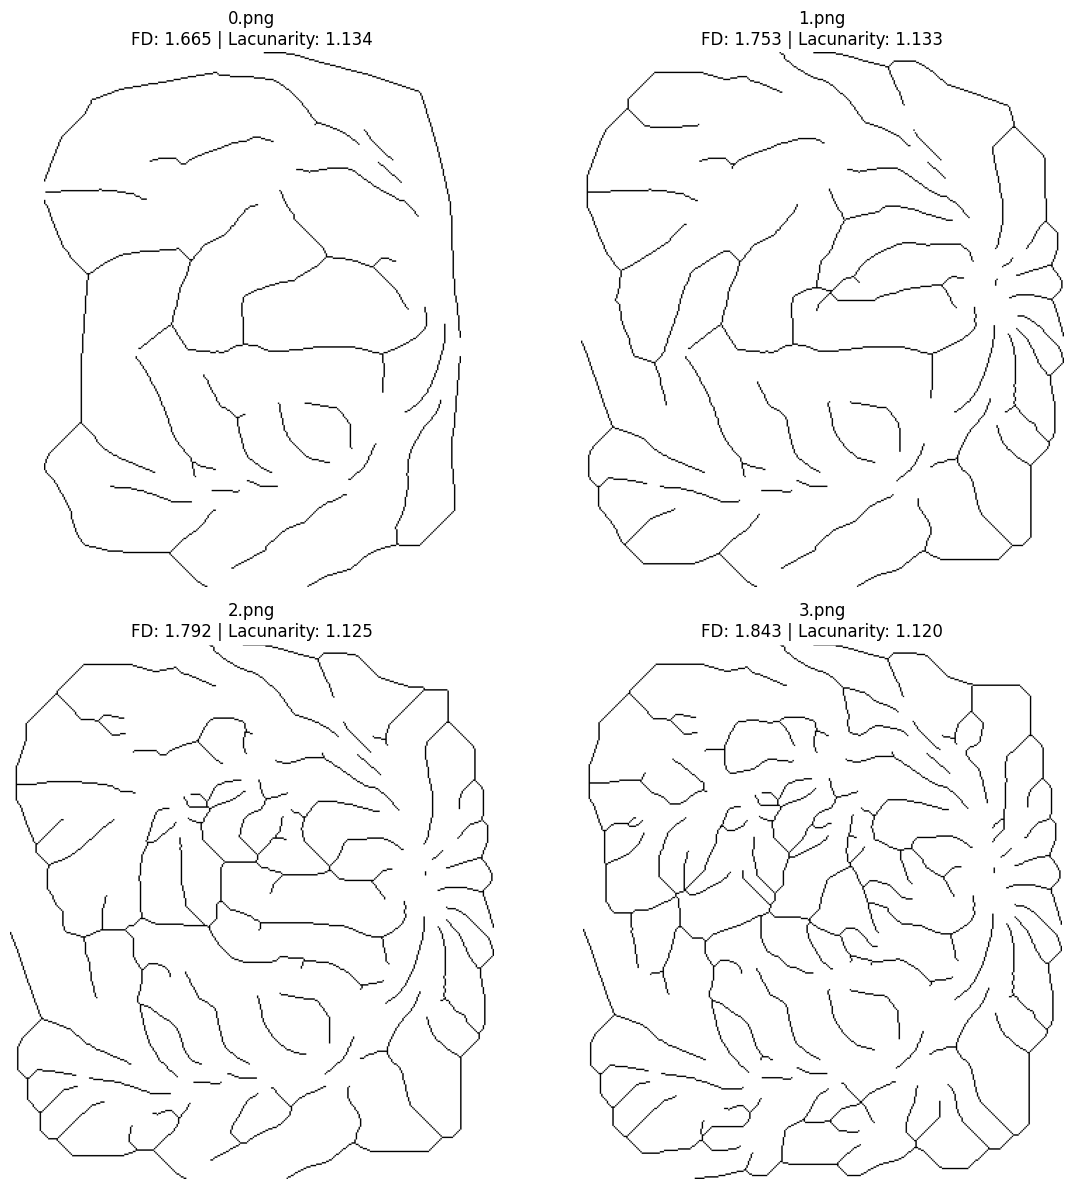

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.ravel()
from skimage import util

for i, ax in enumerate(axes):
    ax.imshow(util.invert(skeletons[i]), cmap="gray")
    fd_text = f"{fractal_dims[i]:.3f}" if np.isfinite(fractal_dims[i]) else "NaN"
    lac_text = f"{lacunarities[i]:.3f}" if np.isfinite(lacunarities[i]) else "NaN"
    ax.set_title(f"{names[i]}\nFD: {fd_text} | Lacunarity: {lac_text}")
    ax.axis("off")

plt.tight_layout()
plt.savefig("FD_lacunarity.pdf")
plt.show()

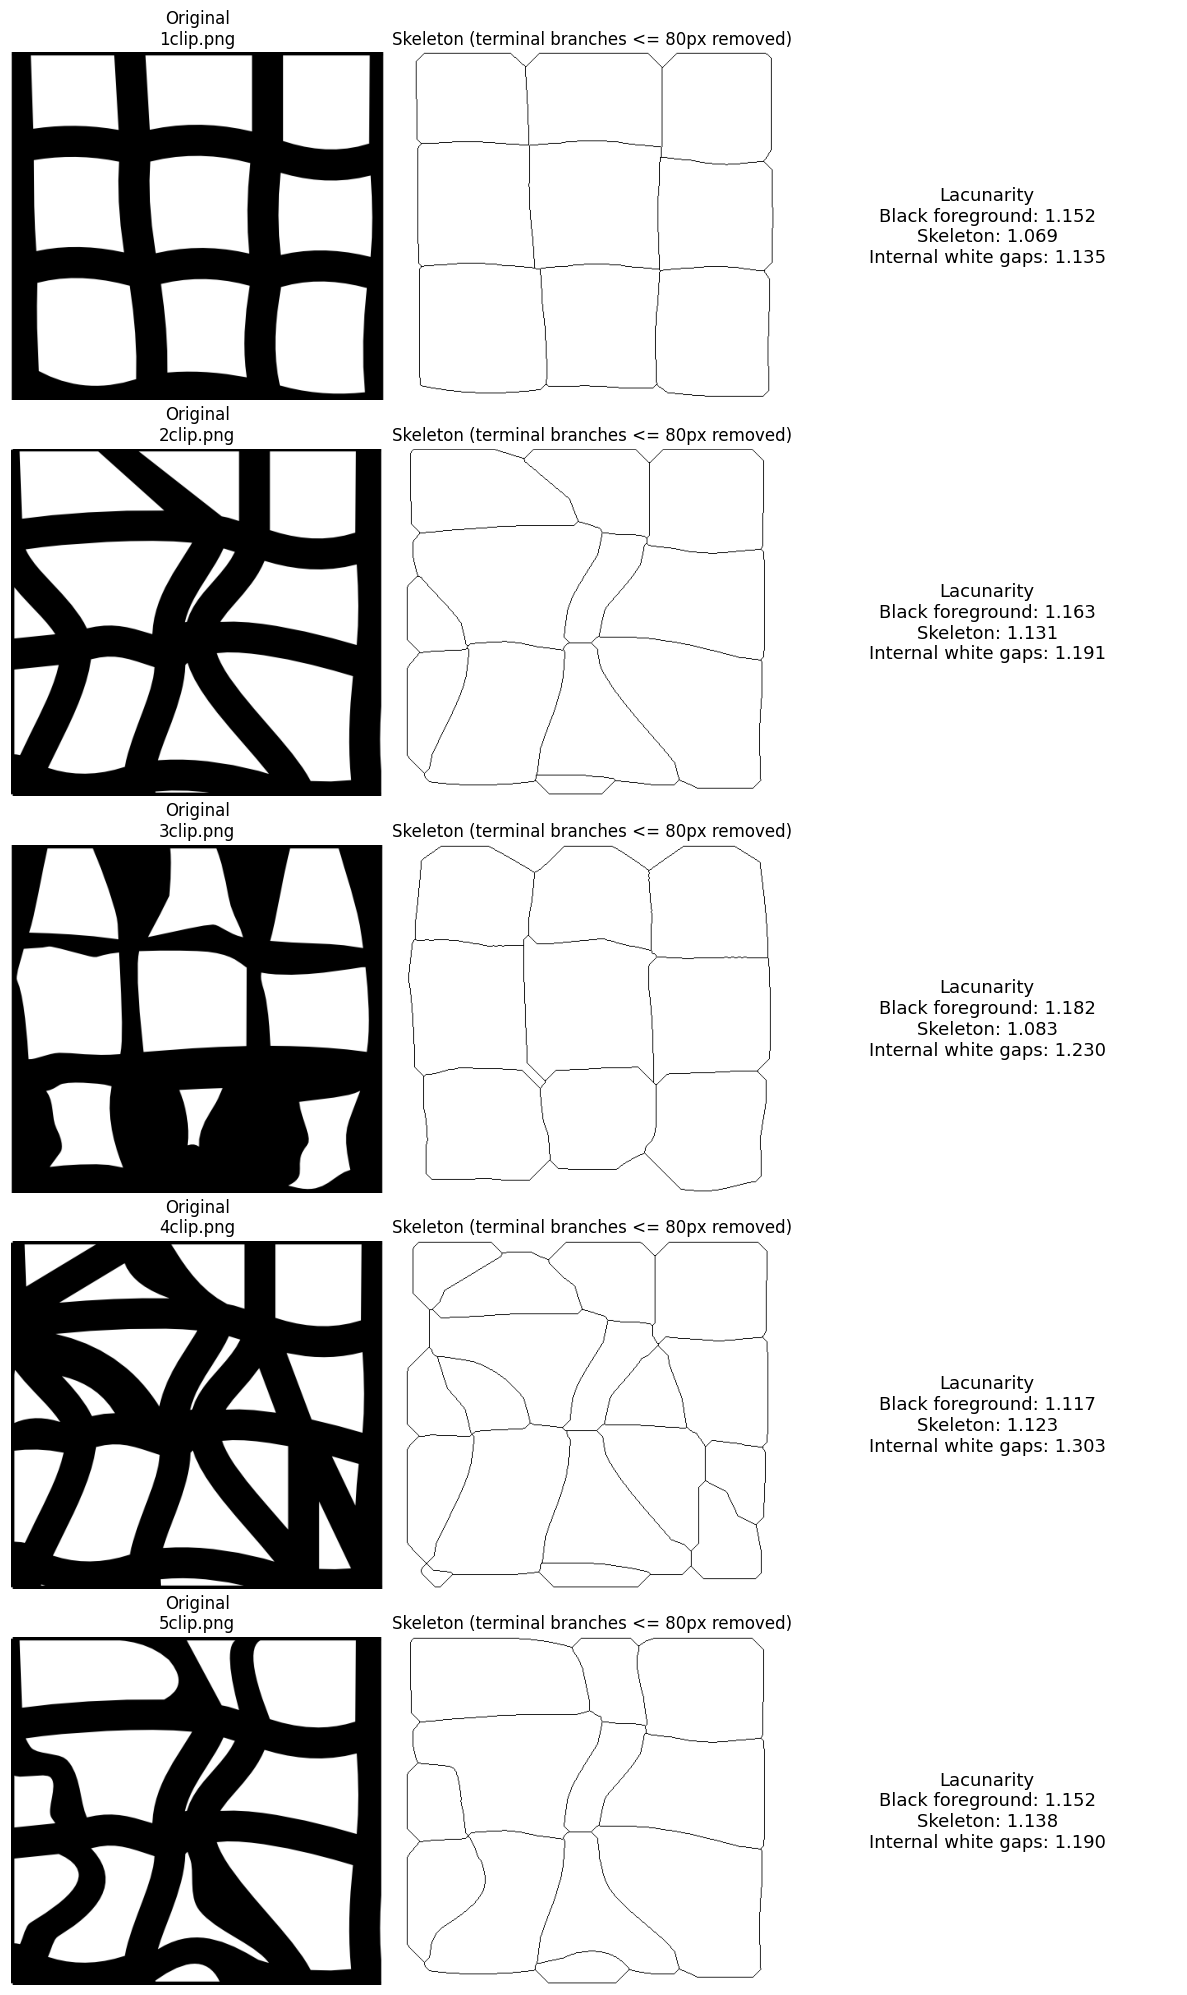

In [28]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage import util
from skimage.filters import threshold_otsu
from skimage.morphology import skeletonize
from scipy.ndimage import label

def load_png_grayscale(path: Path) -> np.ndarray:
    img = Image.open(path)
    # Handle transparency: composite onto white so transparent background is not treated as black.
    if "A" in img.getbands():
        rgba = img.convert("RGBA")
        white_bg = Image.new("RGBA", rgba.size, (255, 255, 255, 255))
        img = Image.alpha_composite(white_bg, rgba).convert("L")
    else:
        img = img.convert("L")
    return np.array(img, dtype=np.float32)

def prune_small_terminal_branches(skeleton: np.ndarray, max_branch_length: int = 12, max_passes: int = 25) -> np.ndarray:
    skel = skeleton.astype(bool).copy()
    h, w = skel.shape

    neighbor_offsets = [
        (dr, dc)
        for dr in (-1, 0, 1)
        for dc in (-1, 0, 1)
        if not (dr == 0 and dc == 0)
    ]

    def neighbors_of(r: int, c: int):
        out = []
        for dr, dc in neighbor_offsets:
            rr, cc = r + dr, c + dc
            if 0 <= rr < h and 0 <= cc < w and skel[rr, cc]:
                out.append((rr, cc))
        return out

    for _ in range(max_passes):
        endpoints = np.argwhere(skel)
        endpoints = [(int(r), int(c)) for r, c in endpoints if len(neighbors_of(int(r), int(c))) == 1]
        if not endpoints:
            break

        to_remove = set()
        for start in endpoints:
            if not skel[start]:
                continue

            path = [start]
            prev = None
            cur = start
            stop_reason = "none"

            while True:
                nbrs = [n for n in neighbors_of(*cur) if n != prev]

                if len(nbrs) == 0:
                    stop_reason = "dead_end"
                    break

                if len(nbrs) > 1:
                    stop_reason = "junction"
                    break

                nxt = nbrs[0]
                path.append(nxt)

                if len(path) > max_branch_length:
                    stop_reason = "too_long"
                    break

                prev, cur = cur, nxt
                degree = len(neighbors_of(*cur))
                if degree == 1:
                    stop_reason = "other_endpoint"
                    break
                if degree >= 3:
                    stop_reason = "junction"
                    break

            if stop_reason in {"dead_end", "other_endpoint", "junction"} and len(path) <= max_branch_length:
                if stop_reason == "junction" and len(path) > 1:
                    to_remove.update(path[:-1])  # keep the junction node itself
                else:
                    to_remove.update(path)

        if not to_remove:
            break

        for r, c in to_remove:
            skel[r, c] = False

    return skel

def internal_gap_mask(binary_foreground: np.ndarray) -> np.ndarray:
    """Return only enclosed white gaps, excluding outer background connected to image border."""
    background = ~binary_foreground.astype(bool)
    labels, _ = label(background)
    if labels.size == 0:
        return np.zeros_like(background, dtype=bool)

    border_labels = set(np.unique(np.concatenate([
        labels[0, :],
        labels[-1, :],
        labels[:, 0],
        labels[:, -1],
    ])))

    enclosed = labels > 0
    for lab in border_labels:
        if lab != 0:
            enclosed[labels == lab] = False
    return enclosed

lacunarity_folder = Path(r"C:\Users\taylorhearn\Dropbox\Diagrams\Affinity_pics\Illustrating_Vascumap_Params\lacunarity\clip")
lacunarity_files = sorted(lacunarity_folder.glob("*.png"))

if not lacunarity_files:
    raise ValueError(f"No PNG files found in {lacunarity_folder}")

max_images = 6
lacunarity_files = lacunarity_files[:max_images]

n = len(lacunarity_files)
fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
if n == 1:
    axes = np.expand_dims(axes, axis=0)

branch_len_px = 80

for row, file_path in enumerate(lacunarity_files):
    gray = load_png_grayscale(file_path)

    try:
        t = threshold_otsu(gray)
    except ValueError:
        t = float(np.mean(gray))

    # Segment dark structures (black) on bright background.
    binary = gray < t

    # Fallback for difficult images where Otsu returns nearly empty/full masks.
    fg_ratio = float(np.mean(binary))
    if fg_ratio < 0.001 or fg_ratio > 0.99:
        binary = gray <= np.percentile(gray, 10)

    skeleton = skeletonize(binary)
    skeleton_pruned = prune_small_terminal_branches(skeleton, max_branch_length=branch_len_px)
    gaps = internal_gap_mask(binary)

    _, lac_full = fractal_dimension_and_lacunarity(binary, remove_branches_first=False)
    _, lac_skel = fractal_dimension_and_lacunarity(skeleton_pruned, remove_branches_first=False)
    _, lac_gaps = fractal_dimension_and_lacunarity(gaps, remove_branches_first=False)

    lac_full_text = f"{lac_full:.3f}" if np.isfinite(lac_full) else "NaN"
    lac_skel_text = f"{lac_skel:.3f}" if np.isfinite(lac_skel) else "NaN"
    lac_gaps_text = f"{lac_gaps:.3f}" if np.isfinite(lac_gaps) else "NaN"
    
    axes[row, 0].imshow(gray, cmap="gray", vmin=0, vmax=255)
    axes[row, 0].set_title(f"Original\n{file_path.name}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(util.invert(skeleton_pruned), cmap="gray")
    axes[row, 1].set_title(f"Skeleton (terminal branches <= {branch_len_px}px removed)")
    axes[row, 1].axis("off")

    axes[row, 2].text(
        0.5,
        0.5,
        (
        f"Lacunarity\n"
        f"Black foreground: {lac_full_text}\n"
        f"Skeleton: {lac_skel_text}\n"
        f"Internal white gaps: {lac_gaps_text}"
        ),
        ha="center",
        va="center",
        fontsize=13,
    )
    axes[row, 2].set_xlim(0, 1)
    axes[row, 2].set_ylim(0, 1)
    axes[row, 2].axis("off")

plt.tight_layout()
plt.savefig("lacunarity.pdf")
plt.show()

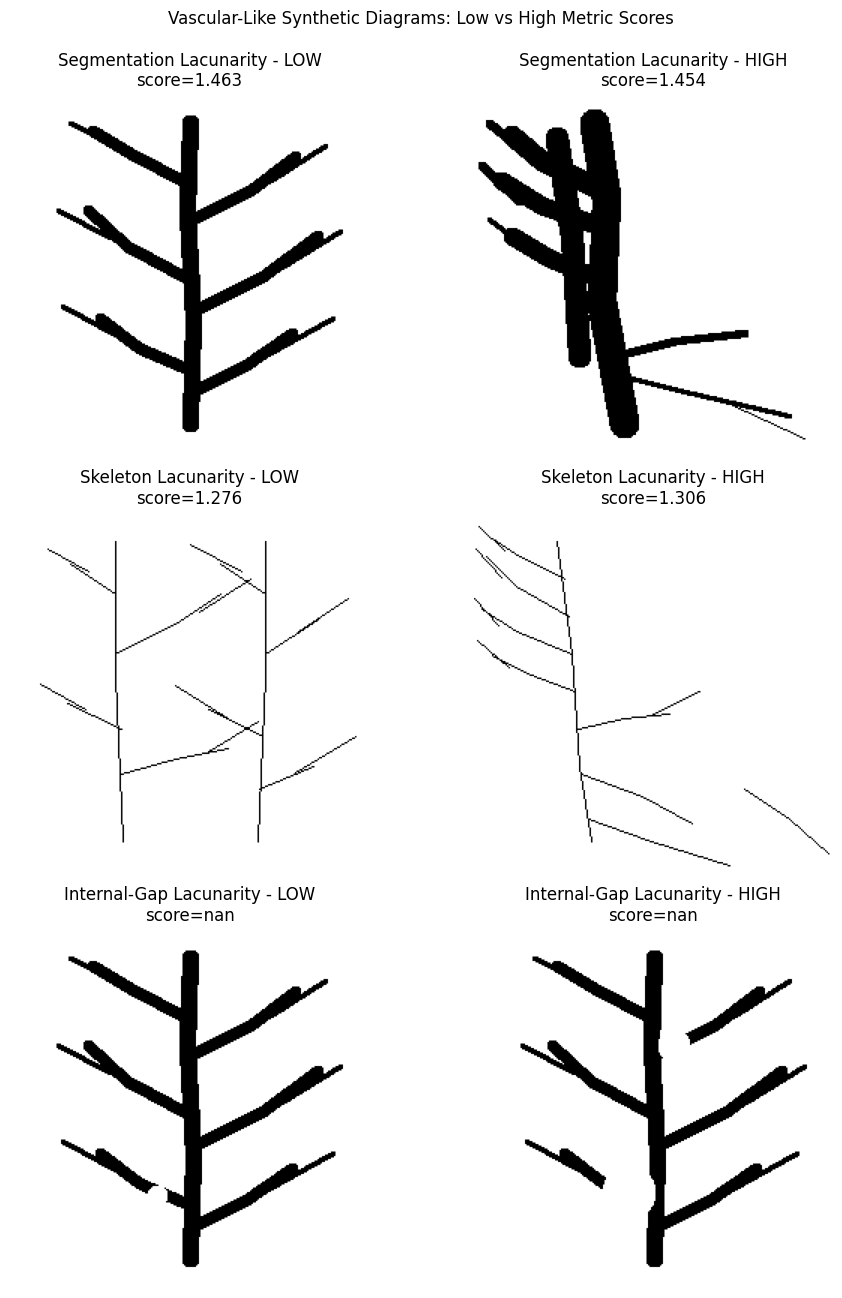

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import util
from skimage.draw import line, disk
from skimage.morphology import skeletonize

def draw_polyline(mask: np.ndarray, points: list[tuple[int, int]], radius: int = 1) -> np.ndarray:
    """Draw a connected polyline as foreground with optional thickness."""
    h, w = mask.shape
    for (r0, c0), (r1, c1) in zip(points[:-1], points[1:]):
        rr, cc = line(r0, c0, r1, c1)
        for r, c in zip(rr, cc):
            if radius <= 1:
                if 0 <= r < h and 0 <= c < w:
                    mask[r, c] = True
            else:
                dr, dc = disk((r, c), radius=radius, shape=mask.shape)
                mask[dr, dc] = True
    return mask

def draw_vascular_tree(mask: np.ndarray, trunk, branches, capillary_radius=1) -> np.ndarray:
    """Compose a vascular-like tree with trunk + side branches + optional twigs."""
    for pts, rad in trunk:
        mask = draw_polyline(mask, pts, radius=rad)

    for branch in branches:
        pts = branch["pts"]
        rad = int(branch.get("radius", 2))
        twigs = branch.get("twigs", [])
        mask = draw_polyline(mask, pts, radius=rad)
        for twig in twigs:
            tpts = twig["pts"]
            trad = int(twig.get("radius", capillary_radius))
            mask = draw_polyline(mask, tpts, radius=trad)
    return mask

def make_segmentation_low(shape=(240, 240)) -> np.ndarray:
    """More even vascular bed: similar caliber and spread -> lower segmentation lacunarity."""
    m = np.zeros(shape, dtype=bool)
    trunk = [
        ([(20, 120), (80, 118), (150, 122), (220, 120)], 6),
    ]
    branches = [
        {"pts": [(60, 118), (40, 80), (25, 55)], "radius": 4, "twigs": [{"pts": [(33, 66), (20, 40)], "radius": 2}]},
        {"pts": [(85, 120), (65, 160), (42, 190)], "radius": 4, "twigs": [{"pts": [(58, 174), (35, 210)], "radius": 2}]},
        {"pts": [(125, 121), (102, 78), (78, 52)], "radius": 4, "twigs": [{"pts": [(96, 66), (78, 32)], "radius": 2}]},
        {"pts": [(145, 123), (123, 167), (95, 205)], "radius": 4, "twigs": [{"pts": [(116, 181), (92, 220)], "radius": 2}]},
        {"pts": [(185, 121), (170, 86), (150, 60)], "radius": 4, "twigs": [{"pts": [(162, 72), (142, 35)], "radius": 2}]},
        {"pts": [(200, 120), (182, 156), (160, 188)], "radius": 4, "twigs": [{"pts": [(175, 170), (150, 215)], "radius": 2}]},
    ]
    return draw_vascular_tree(m, trunk, branches)

def make_segmentation_high(shape=(240, 240)) -> np.ndarray:
    """Clustered thick proximal region + sparse distal bed -> higher segmentation lacunarity."""
    m = np.zeros(shape, dtype=bool)
    trunk = [
        ([(20, 80), (70, 88), (140, 85), (220, 100)], 10),
        ([(30, 55), (95, 65), (175, 70)], 8),
    ]
    branches = [
        {"pts": [(65, 86), (45, 45), (28, 25)], "radius": 7, "twigs": [{"pts": [(40, 35), (20, 10)], "radius": 3}]},
        {"pts": [(90, 88), (75, 45), (58, 18)], "radius": 6, "twigs": [{"pts": [(72, 30), (48, 5)], "radius": 3}]},
        {"pts": [(125, 87), (110, 50), (95, 25)], "radius": 6, "twigs": [{"pts": [(106, 38), (84, 10)], "radius": 2}]},
        {"pts": [(175, 94), (165, 135), (160, 180)], "radius": 3, "twigs": []},
        {"pts": [(188, 97), (200, 145), (215, 210)], "radius": 2, "twigs": [{"pts": [(206, 168), (230, 220)], "radius": 1}]},
    ]
    return draw_vascular_tree(m, trunk, branches)

def make_skeleton_low(shape=(240, 240)) -> np.ndarray:
    """Evenly distributed centerline trees across the field -> lower skeleton lacunarity."""
    m = np.zeros(shape, dtype=bool)
    trunk = [
        ([(20, 70), (110, 70), (220, 75)], 1),
        ([(20, 170), (110, 170), (220, 165)], 1),
    ]
    branches = [
        {"pts": [(55, 70), (35, 40)], "radius": 1, "twigs": [{"pts": [(40, 52), (25, 25)], "radius": 1}]},
        {"pts": [(95, 70), (75, 110), (55, 140)], "radius": 1, "twigs": [{"pts": [(67, 126), (45, 160)], "radius": 1}]},
        {"pts": [(145, 74), (128, 38)], "radius": 1, "twigs": [{"pts": [(132, 50), (115, 20)], "radius": 1}]},
        {"pts": [(175, 74), (165, 110), (158, 145)], "radius": 1, "twigs": [{"pts": [(160, 132), (140, 165)], "radius": 1}]},
        {"pts": [(55, 170), (35, 140)], "radius": 1, "twigs": [{"pts": [(40, 154), (22, 120)], "radius": 1}]},
        {"pts": [(95, 170), (72, 205)], "radius": 1, "twigs": [{"pts": [(80, 192), (58, 225)], "radius": 1}]},
        {"pts": [(150, 168), (132, 132)], "radius": 1, "twigs": [{"pts": [(138, 145), (116, 110)], "radius": 1}]},
        {"pts": [(185, 166), (170, 202)], "radius": 1, "twigs": [{"pts": [(174, 190), (150, 230)], "radius": 1}]},
    ]
    return draw_vascular_tree(m, trunk, branches)

def make_skeleton_high(shape=(240, 240)) -> np.ndarray:
    """One dense vascular cluster with large sparse territory -> higher skeleton lacunarity."""
    m = np.zeros(shape, dtype=bool)
    trunk = [
        ([(20, 55), (95, 65), (170, 70), (220, 78)], 1),
    ]
    branches = [
        {"pts": [(45, 60), (30, 30), (18, 12)], "radius": 1, "twigs": [{"pts": [(26, 20), (10, 3)], "radius": 1}]},
        {"pts": [(70, 63), (50, 28), (30, 8)], "radius": 1, "twigs": [{"pts": [(44, 18), (25, 1)], "radius": 1}]},
        {"pts": [(95, 65), (80, 28), (65, 5)], "radius": 1, "twigs": [{"pts": [(76, 16), (58, 0)], "radius": 1}]},
        {"pts": [(120, 67), (108, 35), (96, 12)], "radius": 1, "twigs": [{"pts": [(104, 23), (86, 2)], "radius": 1}]},
        {"pts": [(145, 69), (138, 100), (135, 130)], "radius": 1, "twigs": [{"pts": [(136, 118), (120, 150)], "radius": 1}]},
        {"pts": [(175, 71), (190, 112), (208, 145)], "radius": 1, "twigs": []},
        {"pts": [(205, 76), (220, 118), (236, 170)], "radius": 1, "twigs": []},
        {"pts": [(185, 180), (205, 210), (228, 236)], "radius": 1, "twigs": []},
    ]
    return draw_vascular_tree(m, trunk, branches)

def add_lumen_holes(mask: np.ndarray, holes: list[tuple[tuple[int, int], int]]) -> np.ndarray:
    out = mask.copy()
    for (r, c), rad in holes:
        rr, cc = disk((r, c), radius=rad, shape=out.shape)
        out[rr, cc] = False
    return out

def make_gap_low(shape=(240, 240)) -> np.ndarray:
    """Vascular bed with relatively uniform enclosed avascular pockets."""
    base = make_segmentation_low(shape=shape)
    holes = [
        ((70, 95), 7), ((95, 140), 7), ((125, 95), 7), ((150, 145), 7),
        ((178, 98), 7), ((105, 62), 6), ((140, 178), 6),
    ]
    return add_lumen_holes(base, holes)

def make_gap_high(shape=(240, 240)) -> np.ndarray:
    """Vascular bed with highly heterogeneous internal void sizes and spacing."""
    base = make_segmentation_low(shape=shape)
    holes = [
        ((62, 92), 3), ((78, 133), 11), ((92, 82), 5), ((109, 149), 15),
        ((132, 96), 4), ((152, 156), 12), ((176, 103), 18), ((120, 63), 2),
    ]
    return add_lumen_holes(base, holes)

def metric_scores(mask: np.ndarray) -> dict:
    sk = skeletonize(mask)
    gaps = internal_gap_mask(mask)
    _, lac_seg = fractal_dimension_and_lacunarity(mask, remove_branches_first=False)
    _, lac_skel = fractal_dimension_and_lacunarity(sk, remove_branches_first=False)
    _, lac_gap = fractal_dimension_and_lacunarity(gaps, remove_branches_first=False)
    return {"seg": lac_seg, "skel": lac_skel, "gap": lac_gap}

examples = [
    ("Segmentation Lacunarity", make_segmentation_low(), make_segmentation_high(), "seg"),
    ("Skeleton Lacunarity", make_skeleton_low(), make_skeleton_high(), "skel"),
    ("Internal-Gap Lacunarity", make_gap_low(), make_gap_high(), "gap"),
]

fig, axes = plt.subplots(3, 2, figsize=(10, 13))
for row, (metric_name, low_img, high_img, key) in enumerate(examples):
    low_scores = metric_scores(low_img)
    high_scores = metric_scores(high_img)

    axes[row, 0].imshow(util.invert(low_img), cmap="gray")
    axes[row, 0].set_title(f"{metric_name} - LOW\nscore={low_scores[key]:.3f}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(util.invert(high_img), cmap="gray")
    axes[row, 1].set_title(f"{metric_name} - HIGH\nscore={high_scores[key]:.3f}")
    axes[row, 1].axis("off")

plt.suptitle("Vascular-Like Synthetic Diagrams: Low vs High Metric Scores", y=0.995, fontsize=12)
plt.tight_layout()
plt.savefig("lacunarity_metric_schematics_vascular_like.pdf")
plt.show()